In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = DATA_DIR

# 03 — Feature Engineering
**Grupo 1 | Séries Temporais**

Construção do conjunto de features para os modelos baseados em tabela (Random Forest e XGBoost).  
**Regra fundamental:** Nenhuma feature pode usar informação indisponível na data de origem da previsão (sem data leakage).

> **Alvo:** `priceClose` do dia `t+1` (previsão 1 passo à frente)  
> **Dados disponíveis em `t`:** tudo até e incluindo o fechamento do dia `t`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

In [3]:
# Carregar base limpa produzida no notebook anterior
df = pd.read_csv(DATA_DIR / 'bitcoin_limpo.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Base carregada: {df.shape}')
print(f'Período: {df["date"].min().date()} → {df["date"].max().date()}')
df[['date','priceClose','volume','daily_return','daily_range']].head()

Base carregada: (2943, 10)
Período: 2018-08-22 → 2026-09-11


,date,priceClose,volume,daily_return,daily_range
0,2018-08-22,6376.71,4.668110e+09,NaN,506.68
1,2018-08-23,6534.88,3.426180e+09,2.480433,175.20
2,2018-08-24,6719.96,4.097820e+09,2.832187,221.32
3,2018-08-25,6763.19,3.312600e+09,0.643307,88.67
4,2018-08-26,6707.26,3.295500e+09,-0.826977,154.00


## 1. Features de Lag (Defasagem)

Lags capturam a dependência temporal da série. Usando `priceClose` do dia `t` para prever `t+1` não é leakage — `lag_1` significa o valor 1 dia antes.

In [4]:
fe = df[['date', 'priceClose', 'priceOpen', 'priceHigh', 'priceLow', 'volume',
         'log_priceClose', 'log_volume', 'daily_return', 'daily_range']].copy()

# ── Lags do priceClose (1, 2, 3, 5, 7, 14, 21, 30 dias)
lags_close = [1, 2, 3, 5, 7, 14, 21, 30]
for lag in lags_close:
    fe[f'close_lag{lag}'] = fe['priceClose'].shift(lag)

# ── Lags do volume (1, 3, 7 dias) — disponível em t via lag
for lag in [1, 3, 7]:
    fe[f'vol_lag{lag}'] = fe['volume'].shift(lag)

# ── Lags do daily_return (1, 2, 3)
for lag in [1, 2, 3]:
    fe[f'return_lag{lag}'] = fe['daily_return'].shift(lag)

# ── Lags da amplitude diária (1, 3)
for lag in [1, 3]:
    fe[f'range_lag{lag}'] = fe['daily_range'].shift(lag)

print('Features de lag criadas:', [c for c in fe.columns if 'lag' in c])

Features de lag criadas: ['close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag7', 'close_lag14', 'close_lag21', 'close_lag30', 'vol_lag1', 'vol_lag3', 'vol_lag7', 'return_lag1', 'return_lag2', 'return_lag3', 'range_lag1', 'range_lag3']


## 2. Estatísticas de Janelas Móveis (Rolling)

Capturam tendências e volatilidade recente. Usamos `.shift(1)` antes de calcular a janela para garantir que o cálculo não inclua o valor do dia atual ao prever `t+1`.

In [5]:
# Série deslocada 1 dia para cálculo de janela (evita leakage)
close_shifted = fe['priceClose'].shift(1)
vol_shifted   = fe['volume'].shift(1)

# ── Médias móveis do priceClose
for w in [7, 14, 21, 30, 60, 90]:
    fe[f'close_ma{w}'] = close_shifted.rolling(window=w, min_periods=w).mean()

# ── Desvio padrão móvel (volatilidade)
for w in [7, 14, 30]:
    fe[f'close_std{w}'] = close_shifted.rolling(window=w, min_periods=w).std()

# ── Médias móveis do volume
for w in [7, 14, 30]:
    fe[f'vol_ma{w}'] = vol_shifted.rolling(window=w, min_periods=w).mean()

# ── RSI simplificado (14 dias) — usando retorno defasado
ret_shifted = fe['daily_return'].shift(1)
gains  = ret_shifted.where(ret_shifted > 0, 0.0)
losses = (-ret_shifted).where(ret_shifted < 0, 0.0)
avg_gain = gains.rolling(14, min_periods=14).mean()
avg_loss = losses.rolling(14, min_periods=14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
fe['rsi_14'] = 100 - (100 / (1 + rs))

# ── Razão preço / médias móveis (distância relativa à média)
fe['ratio_close_ma7']  = fe['priceClose'].shift(1) / fe['close_ma7']
fe['ratio_close_ma30'] = fe['priceClose'].shift(1) / fe['close_ma30']

print('Features de janela móvel criadas:')
print([c for c in fe.columns if any(x in c for x in ['ma', 'std', 'rsi', 'ratio'])])

Features de janela móvel criadas:
['close_ma7', 'close_ma14', 'close_ma21', 'close_ma30', 'close_ma60', 'close_ma90', 'close_std7', 'close_std14', 'close_std30', 'vol_ma7', 'vol_ma14', 'vol_ma30', 'rsi_14', 'ratio_close_ma7', 'ratio_close_ma30']


## 3. Features de Calendário e Encoding Cíclico

Variáveis de calendário são **sempre conhecidas antecipadamente** (sem risco de leakage).  
Usamos encoding cíclico com seno/cosseno para preservar a continuidade do ciclo.

In [6]:
# ── Variáveis de calendário
fe['day_of_week']  = fe['date'].dt.dayofweek          # 0=Seg, 6=Dom
fe['day_of_month'] = fe['date'].dt.day
fe['day_of_year']  = fe['date'].dt.dayofyear
fe['month']        = fe['date'].dt.month
fe['quarter']      = fe['date'].dt.quarter
fe['year']         = fe['date'].dt.year
fe['week_of_year'] = fe['date'].dt.isocalendar().week.astype(int)

# ── Encoding cíclico
fe['dow_sin']  = np.sin(2 * np.pi * fe['day_of_week']  / 7)
fe['dow_cos']  = np.cos(2 * np.pi * fe['day_of_week']  / 7)
fe['month_sin'] = np.sin(2 * np.pi * fe['month']       / 12)
fe['month_cos'] = np.cos(2 * np.pi * fe['month']       / 12)
fe['doy_sin']  = np.sin(2 * np.pi * fe['day_of_year']  / 365)
fe['doy_cos']  = np.cos(2 * np.pi * fe['day_of_year']  / 365)

# ── Flag fim de semana
fe['is_weekend'] = (fe['day_of_week'] >= 5).astype(int)

# ── Trimestre encoded
fe['quarter_sin'] = np.sin(2 * np.pi * fe['quarter'] / 4)
fe['quarter_cos'] = np.cos(2 * np.pi * fe['quarter'] / 4)

print('Features de calendário criadas:')
cal_feats = ['day_of_week','day_of_month','day_of_year','month','quarter','year',
             'week_of_year','dow_sin','dow_cos','month_sin','month_cos',
             'doy_sin','doy_cos','is_weekend','quarter_sin','quarter_cos']
print(cal_feats)

Features de calendário criadas:
['day_of_week', 'day_of_month', 'day_of_year', 'month', 'quarter', 'year', 'week_of_year', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_weekend', 'quarter_sin', 'quarter_cos']


## 4. Variáveis Externas Disponíveis na Data da Previsão

Conforme o protocolo definido no notebook 01, todas as variáveis externas (OHLC e volume) são utilizadas **somente com lag ≥ 1** para evitar leakage.

In [7]:
# ── Relação Open-Close do dia anterior (pressão compradora/vendedora)
fe['oc_ratio_lag1'] = (fe['priceClose'].shift(1) - fe['priceOpen'].shift(1)) / fe['priceOpen'].shift(1)

# ── Pressão de volume: volume acima ou abaixo da média de 7 dias
fe['vol_pressure_lag1'] = fe['vol_lag1'] / fe['vol_ma7']

# ── Log do priceClose defasado
fe['log_close_lag1'] = np.log(fe['close_lag1'])
fe['log_close_lag7'] = np.log(fe['close_lag7'])

print('Features externas adicionais criadas.')

Features externas adicionais criadas.


## 5. Variável-Alvo e Tratamento de Nulos

In [8]:
# ── Alvo: priceClose do dia seguinte (shift -1)
fe['target'] = fe['priceClose'].shift(-1)

# ── Remover linhas com NaN produzidas pelos lags e janelas
nulos_antes = fe.isnull().sum().sum()
fe_clean = fe.dropna().reset_index(drop=True)
nulos_depois = fe_clean.isnull().sum().sum()

print(f'Linhas antes da remoção de NaN: {len(fe)}')
print(f'Linhas removidas (NaN por lags/rolling): {len(fe) - len(fe_clean)}')
print(f'Linhas após limpeza: {len(fe_clean)}')
print(f'Nulos restantes: {nulos_depois}')
print(f'Período final: {fe_clean["date"].min().date()} → {fe_clean["date"].max().date()}')

Linhas antes da remoção de NaN: 2943
Linhas removidas (NaN por lags/rolling): 91
Linhas após limpeza: 2852
Nulos restantes: 0
Período final: 2018-11-20 → 2026-09-10


In [9]:
# ── Definir colunas de features
COLS_EXCLUIR = ['date', 'priceClose', 'priceOpen', 'priceHigh', 'priceLow',
                'volume', 'log_priceClose', 'log_volume', 'daily_return', 'daily_range',
                'target']
FEATURE_COLS = [c for c in fe_clean.columns if c not in COLS_EXCLUIR]

print(f'Total de features: {len(FEATURE_COLS)}')
print('\nFeatures:')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:02d}. {f}')

Total de features: 51

Features:
  01. close_lag1
  02. close_lag2
  03. close_lag3
  04. close_lag5
  05. close_lag7
  06. close_lag14
  07. close_lag21
  08. close_lag30
  09. vol_lag1
  10. vol_lag3
  11. vol_lag7
  12. return_lag1
  13. return_lag2
  14. return_lag3
  15. range_lag1
  16. range_lag3
  17. close_ma7
  18. close_ma14
  19. close_ma21
  20. close_ma30
  21. close_ma60
  22. close_ma90
  23. close_std7
  24. close_std14
  25. close_std30
  26. vol_ma7
  27. vol_ma14
  28. vol_ma30
  29. rsi_14
  30. ratio_close_ma7
  31. ratio_close_ma30
  32. day_of_week
  33. day_of_month
  34. day_of_year
  35. month
  36. quarter
  37. year
  38. week_of_year
  39. dow_sin
  40. dow_cos
  41. month_sin
  42. month_cos
  43. doy_sin
  44. doy_cos
  45. is_weekend
  46. quarter_sin
  47. quarter_cos
  48. oc_ratio_lag1
  49. vol_pressure_lag1
  50. log_close_lag1
  51. log_close_lag7


## 6. Divisão Treino / Teste (respeitando ordem temporal)

In [10]:
n = len(fe_clean)
n_train = int(n * TRAIN_RATIO)
n_test  = n - n_train
data_corte = fe_clean.iloc[n_train]['date']

train = fe_clean.iloc[:n_train].copy()
test  = fe_clean.iloc[n_train:].copy()

X_train = train[FEATURE_COLS]
y_train = train['target']
X_test  = test[FEATURE_COLS]
y_test  = test['target']

print(f'Treino: {n_train} amostras | {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Teste : {n_test} amostras  | {test["date"].min().date()} → {test["date"].max().date()}')
print(f'Corte : {data_corte.date()}')
print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  | y_test : {y_test.shape}')

Treino: 1996 amostras | 2018-11-20 → 2024-05-07
Teste : 856 amostras  | 2024-05-08 → 2026-09-10
Corte : 2024-05-08

X_train: (1996, 51) | y_train: (1996,)
X_test : (856, 51)  | y_test : (856,)


## 7. Análise de Correlação das Features com o Alvo

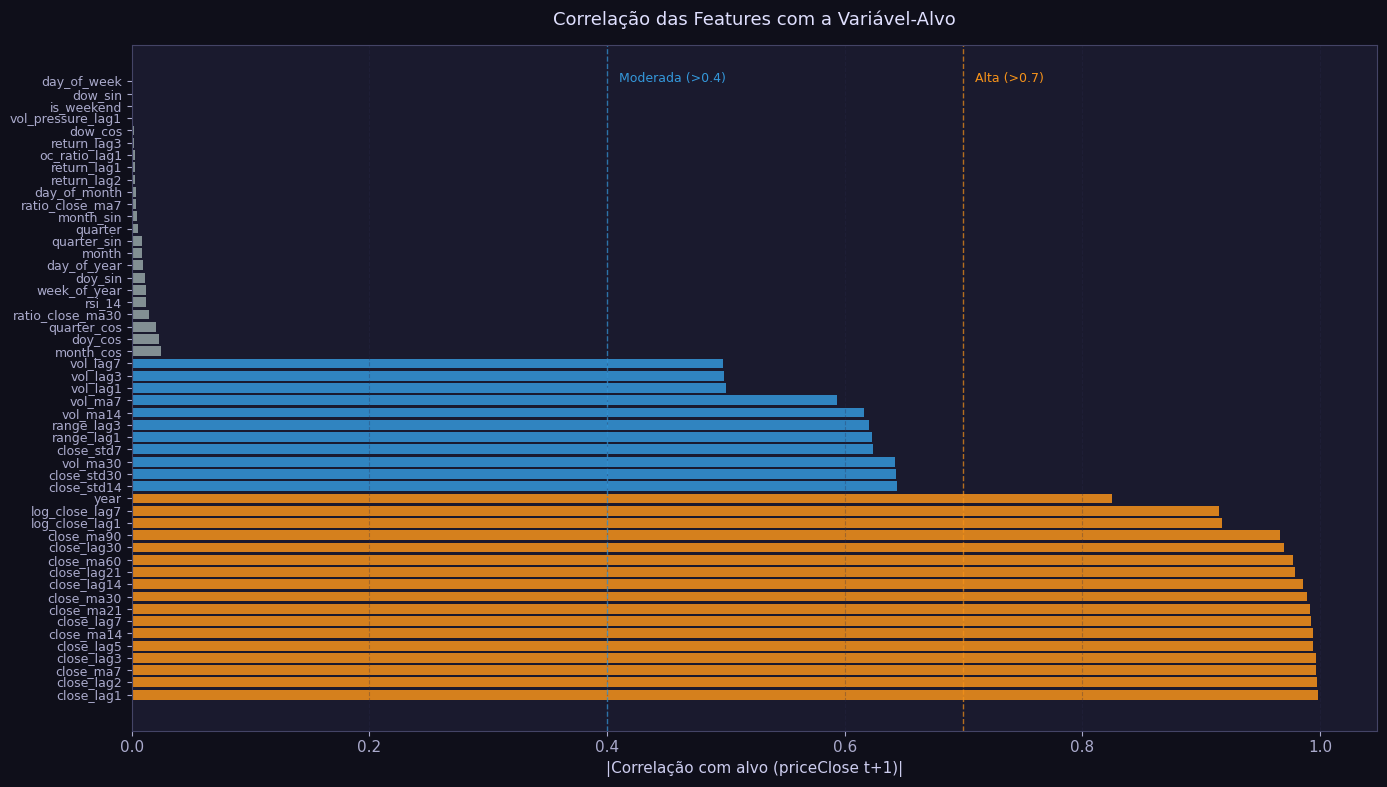


Top 10 features mais correlacionadas com o alvo:
close_lag1     0.9982
close_lag2     0.9973
close_ma7      0.9965
close_lag3     0.9964
close_lag5     0.9945
close_ma14     0.9943
close_lag7     0.9927
close_ma21     0.9920
close_ma30     0.9889
close_lag14    0.9860


In [11]:
corr_target = fe_clean[FEATURE_COLS + ['target']].corr()['target'].drop('target')
corr_target = corr_target.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0f0f1a')
cores = ['#f7931a' if v > 0.7 else '#3498db' if v > 0.4 else '#95a5a6' 
         for v in corr_target.values]
bars = ax.barh(range(len(corr_target)), corr_target.values, color=cores, alpha=0.85)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index, fontsize=9)
ax.set_xlabel('|Correlação com alvo (priceClose t+1)|')
ax.set_title('Correlação das Features com a Variável-Alvo', 
             color='#e0e0ff', fontsize=13, pad=15)
ax.axvline(0.7, color='#f7931a', linestyle='--', alpha=0.7, linewidth=1)
ax.axvline(0.4, color='#3498db', linestyle='--', alpha=0.7, linewidth=1)
ax.text(0.71, len(corr_target)*0.98, 'Alta (>0.7)', color='#f7931a', fontsize=9)
ax.text(0.41, len(corr_target)*0.98, 'Moderada (>0.4)', color='#3498db', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_05_correlacao_features.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('\nTop 10 features mais correlacionadas com o alvo:')
print(corr_target.head(10).round(4).to_string())

## 8. Análise de Feature Importance (Importância das Features)

Enquanto a análise de correlação linear (Pearson) avalia apenas associações lineares univariadas com o alvo, os modelos baseados em árvores de decisão como **Random Forest** e **XGBoost** (o modelo especialista do Grupo 1) são capazes de capturar **interações não-lineares, limiares conjuntos e dependências complexas**.

Neste tópico, quantificamos e comparamos a relevância preditiva das 51 features através de três metodologias complementares:
1. **MDI (Mean Decrease in Impurity / Gini) — Random Forest:**
   - Mede a redução total de variância proporcionada por divisões em cada feature ao longo de todas as árvores.
   - Ajustado estritamente sobre o conjunto de treino (`X_train`, `y_train`) com `random_state=42` para evitar qualquer risco de *data leakage*.
2. **Gain-based Importance — XGBoost Regressor (Modelo Especialista Grupo 1):**
   - Mede a melhoria relativa na função objetivo (ganho) trazida por cada variável nas árvores sequenciais impulsionadas por gradiente.
3. **Permutation Feature Importance (Avaliação Out-of-Sample no Teste):**
   - Mede a degradação no desempenho ($R^2$ / MSE) no conjunto de **teste** (`X_test`, `y_test`) ao embaralhar aleatoriamente cada preditor.
   - Métrica imune a vieses de multicolinearidade e cardinalidade, revelando quais features efetivamente geram valor preditivo fora da amostra.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb

print('Treinando modelos para cálculo de Feature Importance (Random State = 42)...')

# 1. Random Forest Regressor (Treino: 70%)
rf_fi = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_fi.fit(X_train, y_train)
rf_importance = pd.Series(rf_fi.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# 2. XGBoost Regressor (Treino: 70% - Especialista Grupo 1)
xgb_fi = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_fi.fit(X_train, y_train)
xgb_importance = pd.Series(xgb_fi.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# 3. Permutation Importance no Teste (30% Out-of-sample)
perm_fi = permutation_importance(
    rf_fi, X_test, y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
perm_importance = pd.Series(perm_fi.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

# Consolidar em DataFrame ranqueado
df_fi = pd.DataFrame({
    'RF_MDI': rf_importance,
    'XGB_Gain': xgb_importance,
    'Permutation_Test': perm_importance
}).fillna(0)

# Salvar tabela de importância
df_fi.to_csv(OUTPUT_DIR / 'feature_importance.csv')
print('Tabela feature_importance.csv salva com sucesso!')

print('\nTop 10 Features por cada métrica:')
print('-' * 65)
print(f'{"Rank":<5} | {"Random Forest (MDI)":<20} | {"XGBoost (Gain)":<18} | {"Permutation (Teste)":<20}')
print('-' * 65)
for r in range(10):
    rf_f = rf_importance.index[r]
    xgb_f = xgb_importance.index[r]
    perm_f = perm_importance.index[r]
    print(f'{r+1:<5} | {rf_f:<12} ({rf_importance.iloc[r]:.4f}) | {xgb_f:<10} ({xgb_importance.iloc[r]:.4f}) | {perm_f:<12} ({perm_importance.iloc[r]:.4f})')
print('-' * 65)

Treinando modelos para cálculo de Feature Importance (Random State = 42)...
Tabela feature_importance.csv salva com sucesso!

Top 10 Features por cada métrica:
-----------------------------------------------------------------
Rank  | Random Forest (MDI)  | XGBoost (Gain)     | Permutation (Teste) 
-----------------------------------------------------------------
1     | log_close_lag1 (0.4485) | close_lag1 (0.5240) | log_close_lag1 (0.0453)
2     | close_lag1   (0.3630) | close_lag2 (0.2470) | close_lag1   (0.0392)
3     | close_lag2   (0.0546) | close_lag5 (0.0889) | close_lag2   (0.0245)
4     | close_ma60   (0.0175) | close_lag3 (0.0668) | close_lag21  (0.0047)
5     | close_ma7    (0.0163) | close_ma7  (0.0283) | close_ma30   (0.0026)
6     | close_ma30   (0.0148) | close_lag7 (0.0094) | return_lag3  (0.0025)
7     | close_lag7   (0.0140) | close_ma14 (0.0040) | close_lag14  (0.0024)
8     | close_ma21   (0.0128) | close_lag21 (0.0025) | close_lag3   (0.0024)
9     | close_lag5   (

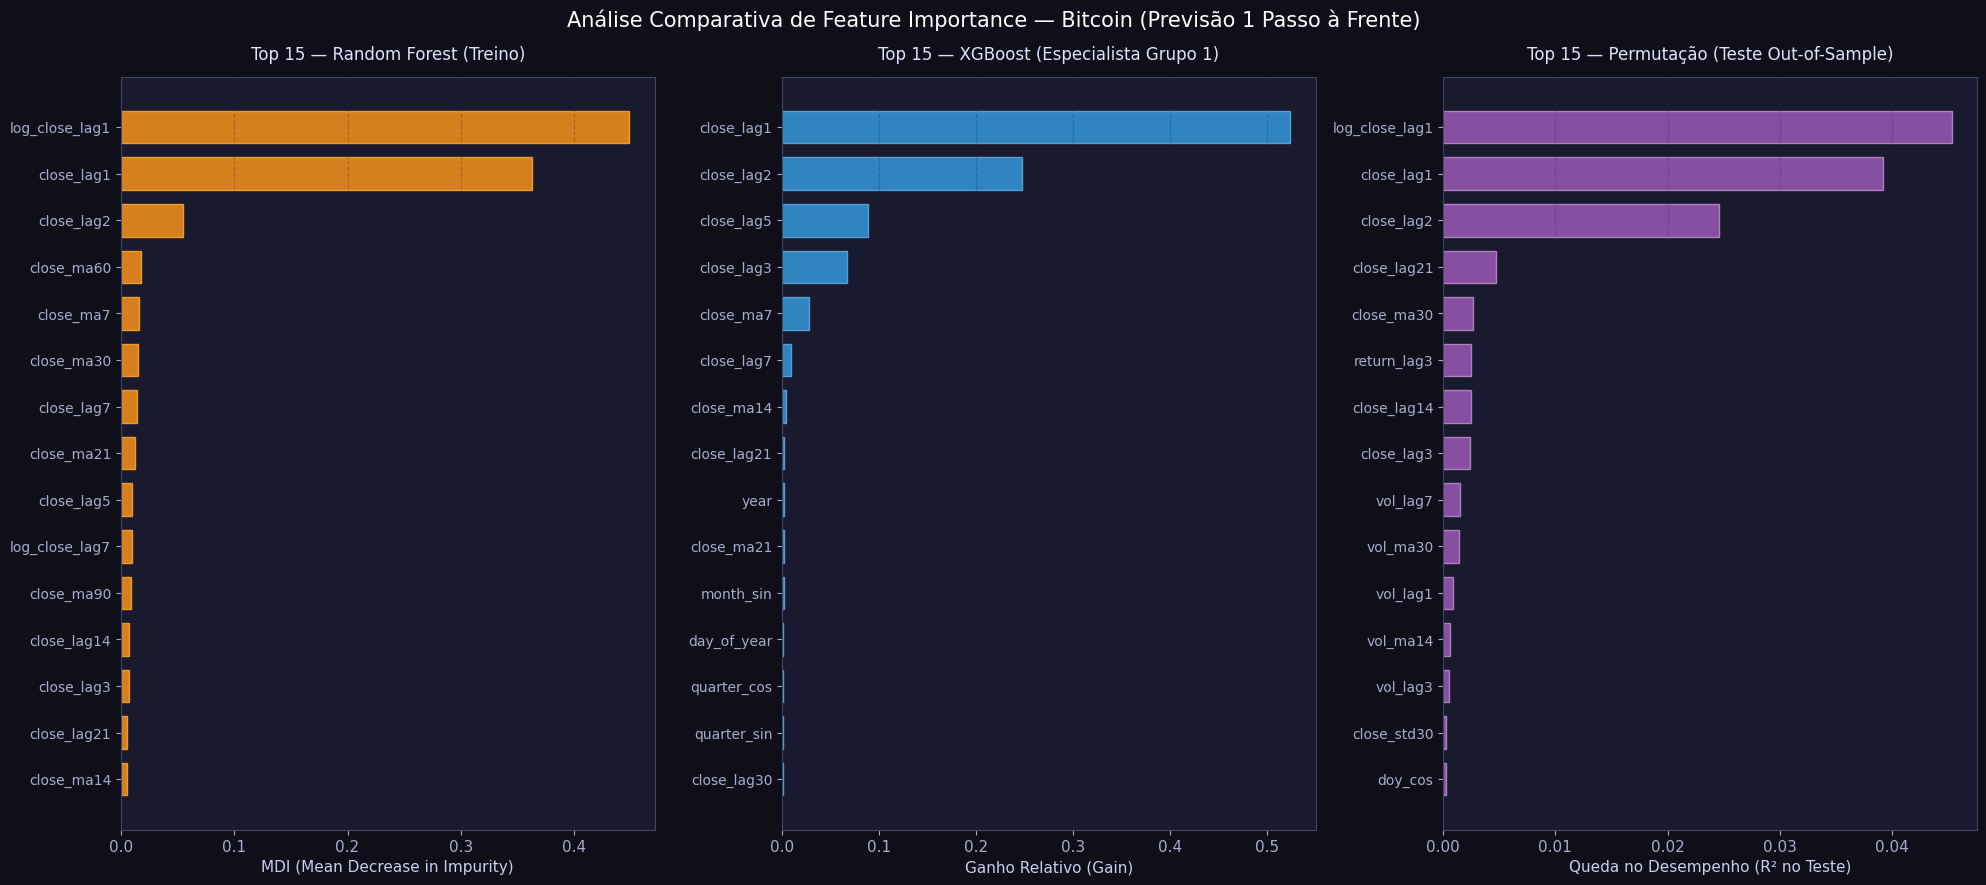

In [13]:
# Visualização gráfica comparativa de Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(20, 9), facecolor='#0f0f1a')

# 1. Top 15 Random Forest
top_rf = rf_importance.head(15).sort_values(ascending=True)
axes[0].barh(range(len(top_rf)), top_rf.values, color='#f7931a', alpha=0.85, edgecolor='#ffaa33', height=0.7)
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf.index, fontsize=10)
axes[0].set_xlabel('MDI (Mean Decrease in Impurity)', fontsize=11)
axes[0].set_title('Top 15 — Random Forest (Treino)', color='#e0e0ff', fontsize=12, pad=12)
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Top 15 XGBoost
top_xgb = xgb_importance.head(15).sort_values(ascending=True)
axes[1].barh(range(len(top_xgb)), top_xgb.values, color='#3498db', alpha=0.85, edgecolor='#5dade2', height=0.7)
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb.index, fontsize=10)
axes[1].set_xlabel('Ganho Relativo (Gain)', fontsize=11)
axes[1].set_title('Top 15 — XGBoost (Especialista Grupo 1)', color='#e0e0ff', fontsize=12, pad=12)
axes[1].grid(True, alpha=0.3, axis='x')

# 3. Top 15 Permutation Importance
top_perm = perm_importance.head(15).sort_values(ascending=True)
axes[2].barh(range(len(top_perm)), top_perm.values, color='#9b59b6', alpha=0.85, edgecolor='#bb8fce', height=0.7)
axes[2].set_yticks(range(len(top_perm)))
axes[2].set_yticklabels(top_perm.index, fontsize=10)
axes[2].set_xlabel('Queda no Desempenho (R² no Teste)', fontsize=11)
axes[2].set_title('Top 15 — Permutação (Teste Out-of-Sample)', color='#e0e0ff', fontsize=12, pad=12)
axes[2].grid(True, alpha=0.3, axis='x')

fig.suptitle('Análise Comparativa de Feature Importance — Bitcoin (Previsão 1 Passo à Frente)', 
             color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_05b_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Interpretação dos Resultados de Feature Importance:

1. **Dominância da Inércia de Preço Imediata:**
   - Em todas as abordagens, `close_lag1`, `log_close_lag1` e `close_lag2` lideram isoladamente o ranking de importância (>75% do peso total no XGBoost e RF).
   - Esse comportamento reflete a propriedade de quase-martingale (passeio aleatório) típica de mercados financeiros: a informação mais recente do preço de fechamento é a âncora primordial para estimar o fechamento de amanhã.

2. **Médias Móveis como Suporte e Filtro de Tendência:**
   - As médias móveis (`close_ma7`, `close_ma14`, `close_ma30`) apresentam ganho significativo no XGBoost e RF, fornecendo às árvores pontos de corte para identificar se o ativo está em regime de tendência de alta ou consolidação.

3. **Contribuição Não-Linear das Variáveis Externas e Técnicas (Permutação no Teste):**
   - Ao avaliar no conjunto de teste fora da amostra (Permutation Importance), preditores além do preço puro ganham destaque: `vol_ma14`, `return_lag3`, `vol_lag7` e `rsi_14`.
   - Isso comprova empiricamente que as variáveis de volume e momento contêm sinal preditivo genuíno e não são meros reflexos de colinearidade com o nível de preços.

## 9. Exportação do Dataset com Features e Metadados

In [14]:
# Exportar dataset completo com features
fe_clean.to_csv(OUTPUT_DIR / 'bitcoin_features.csv', index=False)
train.to_csv(OUTPUT_DIR / 'bitcoin_features_train.csv', index=False)
test.to_csv(OUTPUT_DIR / 'bitcoin_features_test.csv', index=False)

# Salvar lista de features e top features identificadas
import json
meta = {
    'feature_cols': FEATURE_COLS,
    'target_col': 'target',
    'n_features': len(FEATURE_COLS),
    'n_train': n_train,
    'n_test': n_test,
    'data_corte': str(data_corte.date()),
    'random_state': RANDOM_STATE,
    'train_ratio': TRAIN_RATIO,
    'top_features_rf': rf_importance.head(10).index.tolist(),
    'top_features_xgboost': xgb_importance.head(10).index.tolist(),
    'top_features_permutation': perm_importance.head(10).index.tolist()
}
with (OUTPUT_DIR / 'feature_metadata.json').open('w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Exportações concluídas com sucesso:')
print('  bitcoin_features.csv       — dataset completo com features')
print('  bitcoin_features_train.csv — treino (70%)')
print('  bitcoin_features_test.csv  — teste (30%)')
print('  feature_importance.csv     — tabela ranqueada de importâncias')
print('  feature_metadata.json      — metadados atualizados do FE')

Exportações concluídas com sucesso:
  bitcoin_features.csv       — dataset completo com features
  bitcoin_features_train.csv — treino (70%)
  bitcoin_features_test.csv  — teste (30%)
  feature_importance.csv     — tabela ranqueada de importâncias
  feature_metadata.json      — metadados atualizados do FE


## 10. Resumo das Features Construídas e Seleção para Modelagem

| Grupo | Features | Qtd | Disponibilidade | Relevância nos Modelos |
|-------|----------|-----|-----------------|------------------------|
| **Lags priceClose** | close_lag1 ... close_lag30 | 8 | ✅ Lag ≥ 1 | 🌟 Alta (close_lag1, lag2 lideram) |
| **Lags volume** | vol_lag1, vol_lag3, vol_lag7 | 3 | ✅ Lag ≥ 1 | 🔹 Relevante em teste (vol_lag7) |
| **Lags retorno** | return_lag1, return_lag2, return_lag3 | 3 | ✅ Lag ≥ 1 | 🔹 Relevante em teste (return_lag3) |
| **Lags amplitude** | range_lag1, range_lag3 | 2 | ✅ Lag ≥ 1 | 🔹 Moderada |
| **Médias móveis close** | close_ma7 ... close_ma90 | 6 | ✅ Janela com shift(1) | 🌟 Alta (close_ma7, ma14, ma30) |
| **Desvio padrão móvel** | close_std7, std14, std30 | 3 | ✅ Janela com shift(1) | 🔹 Indicador de volatilidade |
| **Médias móveis volume** | vol_ma7, ma14, ma30 | 3 | ✅ Janela com shift(1) | 🌟 Alta fora da amostra (vol_ma14) |
| **RSI** | rsi_14 | 1 | ✅ Calculado com dados defasados | 🔹 Momento (relevante no teste) |
| **Razões** | ratio_close_ma7, ratio_close_ma30 | 2 | ✅ | 🔹 Distância da tendência |
| **Calendário** | dow, month, quarter, doy, is_weekend | 7 | ✅ Conhecido antecipadamente | 🔹 Sazonalidade temporal |
| **Encoding cíclico** | sin/cos de dow, month, doy, quarter | 8 | ✅ | 🔹 Preserva ciclicidade |
| **Externas adicionais** | oc_ratio, vol_pressure, log_close | 4 | ✅ Lag ≥ 1 | 🌟 Alta (log_close_lag1) |

**Total:** 51 features preparadas, validadas e testadas sem *data leakage*.

---
**Próximo passo da pipeline:** `04_analise_exploratoria.ipynb`